In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torch.optim.lr_scheduler import ReduceLROnPlateau
from transformers import BertTokenizer, BertForSequenceClassification
from transformers import AdamW, get_scheduler


import re
from nltk.corpus import stopwords
from nltk.stem import RSLPStemmer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer


from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV, ParameterSampler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from xgboost import XGBClassifier

# Reading Data

In [8]:
olist_customer = pd.read_csv('olist_customers_dataset.csv')
olist_geolocation = pd.read_csv('olist_geolocation_dataset.csv')
olist_orders = pd.read_csv('olist_orders_dataset.csv')
olist_order_items = pd.read_csv('olist_order_items_dataset.csv')
olist_order_payments = pd.read_csv('olist_order_payments_dataset.csv')
olist_order_reviews = pd.read_csv('olist_order_reviews_dataset.csv')
olist_products = pd.read_csv('olist_products_dataset.csv')
olist_sellers = pd.read_csv('olist_sellers_dataset.csv')

In [9]:
# Collections for each dataset
datasets = [olist_customer, olist_geolocation, olist_orders, olist_order_items, olist_order_payments,
            olist_order_reviews, olist_products, olist_sellers]
names = ['olist_customer', 'olist_geolocation', 'olist_orders', 'olist_order_items', 'olist_order_payments',
         'olist_order_reviews', 'olist_products', 'olist_sellers']

# Creating a DataFrame with useful information about all datasets
data_info = pd.DataFrame({})
data_info['dataset'] = names
data_info['n_rows'] = [df.shape[0] for df in datasets]
data_info['n_cols'] = [df.shape[1] for df in datasets]
data_info['null_amount'] = [df.isnull().sum().sum() for df in datasets]
data_info['qty_null_columns'] = [len([col for col, null in df.isnull().sum().items() if null > 0]) for df in datasets]
data_info['null_columns'] = [', '.join([col for col, null in df.isnull().sum().items() if null > 0]) for df in datasets]

data_info.style.background_gradient()

,dataset,n_rows,n_cols,null_amount,qty_null_columns,null_columns
0,olist_customer,99441,5,0,0,
1,olist_geolocation,1000163,5,0,0,
2,olist_orders,99441,8,4908,3,"order_approved_at, order_delivered_carrier_date, order_delivered_customer_date"
3,olist_order_items,112650,7,0,0,
4,olist_order_payments,103886,5,0,0,
5,olist_order_reviews,99224,7,145903,2,"review_comment_title, review_comment_message"
6,olist_products,32951,9,2448,8,"product_category_name, product_name_lenght, product_description_lenght, product_photos_qty, product_weight_g, product_length_cm, product_height_cm, product_width_cm"
7,olist_sellers,3095,4,0,0,


In [10]:
df_overview_list = []
name_col = []

for name, df in zip(names, datasets):
    for col in df.columns:
        num_nulls = df[col].isnull().sum()  # 缺失值数量
        percent_null = (num_nulls / len(df)) * 100  # 缺失值占比
        dtype = df[col].dtype  # 数据类型
        num_unique_categories = df[col].nunique() if df[col].dtype == 'object' else 0  # 类别数量

        df_overview_list.append([name, col, num_nulls, percent_null, dtype, num_unique_categories])
        
df_overview = pd.DataFrame(df_overview_list, columns=['dataset_name', 'feature', 'num_nulls', 'percent_null', 'dtype', 'num_unique_categories'])
df_overview

,dataset_name,feature,num_nulls,percent_null,dtype,num_unique_categories
0,olist_customer,customer_id,0,0.000000,object,99441
1,olist_customer,customer_unique_id,0,0.000000,object,96096
2,olist_customer,customer_zip_code_prefix,0,0.000000,int64,0
3,olist_customer,customer_city,0,0.000000,object,4119
4,olist_customer,customer_state,0,0.000000,object,27
5,olist_geolocation,geolocation_zip_code_prefix,0,0.000000,int64,0
6,olist_geolocation,geolocation_lat,0,0.000000,float64,0
7,olist_geolocation,geolocation_lng,0,0.000000,float64,0
8,olist_geolocation,geolocation_city,0,0.000000,object,8011
9,olist_geolocation,geolocation_state,0,0.000000,object,27


# Natural Language Processing

In [11]:
df_comments = olist_order_reviews.loc[:, ['review_score', 'review_comment_message']]
df_comments = df_comments.dropna(subset=['review_comment_message'])
df_comments = df_comments.reset_index(drop=True)
print(f'Dataset shape: {df_comments.shape}')
df_comments.columns = ['score', 'comment']
df_comments.head()

Dataset shape: (40977, 2)


,score,comment
0,5,Recebi bem antes do prazo estipulado.
1,5,Parabéns lojas lannister adorei comprar pela I...
2,4,aparelho eficiente. no site a marca do aparelh...
3,4,"Mas um pouco ,travando...pelo valor ta Boa.\r\n"
4,5,"Vendedor confiável, produto ok e entrega antes..."


去除换行符，替换为空格

In [12]:
def re_linebreak(text_list):
    return [re.sub('[\n\r]', ' ', r) for r in text_list]

In [13]:
reviews = list(df_comments['comment'].values)
reviews_linebreak = re_linebreak(reviews)
df_comments['re_linebreak'] = reviews_linebreak
print(reviews[48])
print(reviews_linebreak[48])

Estava faltando apenas um produto, eu recebi hoje , muito obrigada!
Tudo certo!

Att 

Elenice.
Estava faltando apenas um produto, eu recebi hoje , muito obrigada!  Tudo certo!    Att     Elenice.


去除URL，替换为' link '

In [14]:
def re_hyperlinks(text_list):
    pattern = 'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\(\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+'
    return [re.sub(pattern, ' link ', r) for r in text_list]

In [15]:
reviews_hyperlinks = re_hyperlinks(reviews_linebreak)
df_comments['re_hyperlinks'] = reviews_hyperlinks
print(reviews_linebreak[10607])
print(reviews_hyperlinks[10607])

comprei o produto pela cor ilustrada pelo site da loja americana, no site mostra ser preto http://prntscr.com/jkx7hr quando o produto chegou aqui veio todos com a mesma cor, tabaco http://prntscr.com/
comprei o produto pela cor ilustrada pelo site da loja americana, no site mostra ser preto  link  quando o produto chegou aqui veio todos com a mesma cor, tabaco  link 


日期替换为' data '

In [16]:
def re_dates(text_list):
    pattern = '([0-2][0-9]|(3)[0-1])(\/|\.)(((0)[0-9])|((1)[0-2]))(\/|\.)\d{2,4}'
    return [re.sub(pattern, ' data ', r) for r in text_list]

In [17]:
reviews_dates = re_dates(reviews_hyperlinks)
df_comments['re_dates'] = reviews_dates
print(reviews_hyperlinks[567])
print(reviews_dates[567])

ENTREGA MUITO DEMORADA, COMPREI EM 26/03/2018 E ATÉ AGORA NÃO RECEBI OS PRODUTOS
ENTREGA MUITO DEMORADA, COMPREI EM  data  E ATÉ AGORA NÃO RECEBI OS PRODUTOS


钱替换为' dinheiro '

In [18]:
def re_money(text_list):
    pattern = '[R]{0,1}\$[ ]{0,}\d+(,|\.)\d+'
    return [re.sub(pattern, ' dinheiro ', r) for r in text_list]

In [19]:
reviews_money = re_money(reviews_dates)
print(reviews_dates[45])
print(reviews_money[45])

Este foi o pedido  Balde Com 128 Peças - Blocos De Montar 2 un - R$ 25,00 cada (NÃO FOI ENTREGUE)  Vendido e entregue targaryen  Tapete de Eva Nº Letras 36 Peças Crianças 1 un - R$ 35,90 (ESTE FOI ENTREG
Este foi o pedido  Balde Com 128 Peças - Blocos De Montar 2 un -  dinheiro  cada (NÃO FOI ENTREGUE)  Vendido e entregue targaryen  Tapete de Eva Nº Letras 36 Peças Crianças 1 un -  dinheiro  (ESTE FOI ENTREG


数字替换为' numero '

In [20]:
def re_numbers(text_list):
    return [re.sub('[0-9]+', ' numero ', r) for r in text_list]

In [21]:
reviews_numbers = re_numbers(reviews_money)
df_comments['re_numbers'] = reviews_numbers
print(reviews_money[45])
print(reviews_numbers[45])

Este foi o pedido  Balde Com 128 Peças - Blocos De Montar 2 un -  dinheiro  cada (NÃO FOI ENTREGUE)  Vendido e entregue targaryen  Tapete de Eva Nº Letras 36 Peças Crianças 1 un -  dinheiro  (ESTE FOI ENTREG
Este foi o pedido  Balde Com  numero  Peças - Blocos De Montar  numero  un -  dinheiro  cada (NÃO FOI ENTREGUE)  Vendido e entregue targaryen  Tapete de Eva Nº Letras  numero  Peças Crianças  numero  un -  dinheiro  (ESTE FOI ENTREG


否定词替换为' negação '

In [22]:
def re_negation(text_list):
    return [re.sub('([nN][ãÃaA][oO]|[ñÑ]| [nN] )', ' negação ', r) for r in text_list]

In [23]:
reviews_negation = re_negation(reviews_numbers)
df_comments['re_negation'] = reviews_negation
print(reviews_numbers[11])
print(reviews_negation[11])

Não gostei ! Comprei gato por lebre
 negação  gostei ! Comprei gato por lebre


特殊字符替换为空格

In [24]:
def re_special_chars(text_list):
    return [re.sub('\W', ' ', r) for r in text_list]

In [25]:
reviews_special_chars = re_special_chars(reviews_negation)
df_comments['re_special_chars'] = reviews_special_chars
print(reviews_negation[133])
print(reviews_special_chars[133])

Cada vez que compro mais fico satisfeita parabéns pela honestidade com seus clientes 👏👏👏👏?
Cada vez que compro mais fico satisfeita parabéns pela honestidade com seus clientes      


去除多余空格

In [26]:
def re_whitespaces(text_list):
    white_spaces = [re.sub('\s+', ' ', r) for r in text_list]
    white_spaces_end = [re.sub('[ \t]+$', '', r) for r in white_spaces]
    return white_spaces_end

In [27]:
reviews_whitespaces = re_whitespaces(reviews_special_chars)
df_comments['re_whitespaces'] = reviews_whitespaces
print(reviews_special_chars[3])
print(reviews_whitespaces[3])

Mas um pouco  travando   pelo valor ta Boa   
Mas um pouco travando pelo valor ta Boa


In [28]:
df_comments['score'] = df_comments['score'].astype(int)

# 使用 `re_whitespaces` 作为训练文本
if 're_whitespaces' in df_comments.columns:
    df_comments['text'] = df_comments['re_whitespaces']

# 评分转换为 0-4 作为模型标签（1-5 变为 0-4）
df_comments['label'] = df_comments['score'] - 1

# 划分数据集（80% 训练，10% 验证，10% 测试）
train_texts, test_texts, train_labels, test_labels = train_test_split(
    df_comments['text'].tolist(), df_comments['label'].tolist(), test_size=0.2, random_state=42
)
val_texts, test_texts, val_labels, test_labels = train_test_split(
    test_texts, test_labels, test_size=0.5, random_state=42
)

In [29]:
# 加载 BERT 预训练模型的 tokenizer
tokenizer = BertTokenizer.from_pretrained("./bert_model/")

# Tokenize 数据，输出 input_ids 和 attention_mask 供 BERT 使用
train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=128)
val_encodings = tokenizer(val_texts, truncation=True, padding=True, max_length=128)
test_encodings = tokenizer(test_texts, truncation=True, padding=True, max_length=128)

In [30]:
class SentimentDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

# 创建 PyTorch Dataset
train_dataset = SentimentDataset(train_encodings, train_labels)
val_dataset = SentimentDataset(val_encodings, val_labels)
test_dataset = SentimentDataset(test_encodings, test_labels)

In [31]:
batch_sizes = [16, 32]
learning_rates = [5e-5, 3e-5, 2e-5]
num_epochs_list = [2, 3, 4]

# 生成所有超参数组合
param_grid = list(itertools.product(batch_sizes, learning_rates, num_epochs_list))
best_val_acc = 0
best_params = None
best_model = None

def train_model(model, train_loader, val_loader, optimizer, lr_scheduler, epochs):
    best_val_loss = float("inf")
    patience_counter = 0
    patience = 3  # Early Stopping 的 patience
    
    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for batch in train_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            loss = outputs.loss
            total_loss += loss.item()

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            lr_scheduler.step()

        avg_loss = total_loss / len(train_loader)
        print(f"Epoch {epoch+1}: Training Loss = {avg_loss:.4f}")

        # 评估验证集
        val_acc, _, _, _ = evaluate(model, val_loader)
        print(f"Validation Accuracy: {val_acc:.4f}")

        # Early Stopping 逻辑
        if avg_loss < best_val_loss:
            best_val_loss = avg_loss
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print("Early stopping triggered!")
            break

    return val_acc

# 评估函数
def evaluate(model, data_loader):
    model.eval()
    predictions, true_labels = [], []

    with torch.no_grad():
        for batch in data_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            logits = outputs.logits
            preds = torch.argmax(logits, dim=-1).cpu().numpy()
            labels = batch["labels"].cpu().numpy()

            predictions.extend(preds)
            true_labels.extend(labels)

    acc = accuracy_score(true_labels, predictions)
    report = classification_report(true_labels, predictions, target_names=["1", "2", "3", "4", "5"])
    return acc, report, true_labels, predictions

In [90]:
# 遍历所有超参数组合
for batch_size, lr, num_epochs in param_grid:
    print(f"\n Training with batch_size={batch_size}, learning_rate={lr}, num_epochs={num_epochs}")

    # 重新创建 BERT 模型
    model = BertForSequenceClassification.from_pretrained("./bert_model/", num_labels=5)
    device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
    model.to(device)
    
    # 重新定义优化器和调度器
    optimizer = optim.AdamW(model.parameters(), lr=lr)
    num_training_steps = len(train_loader) * num_epochs
    lr_scheduler = get_scheduler("linear", optimizer=optimizer, num_warmup_steps=0, num_training_steps=num_training_steps)

    # 重新创建 DataLoader
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    # 训练模型
    val_acc = train_model(model, train_loader, val_loader, optimizer, lr_scheduler, epochs=num_epochs)

    # 记录最佳超参数
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_params = {"batch_size": batch_size, "learning_rate": lr, "num_epochs": num_epochs}
        best_model = model

print("\n Best Hyperparameters:", best_params)
print(f" Best Validation Accuracy: {best_val_acc:.4f}")

# 用最佳模型在测试集上评估
if best_model:
    print("\n Evaluating on Test Set with Best Model...")
    test_acc, test_report, test_true, test_pred = evaluate(best_model, test_loader)
    print(f"Test Accuracy: {test_acc:.4f}")
    print(test_report)


 Training with batch_size=16, learning_rate=5e-05, num_epochs=2


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at ./bert_model/ and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1: Training Loss = 0.8881


/nfs/home/Tyrants/venv/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/nfs/home/Tyrants/venv/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/nfs/home/Tyrants/venv/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Validation Accuracy: 0.6037
Epoch 2: Training Loss = 0.7829


...

Validation Accuracy: 0.6999
Epoch 2: Training Loss = 0.7427
Validation Accuracy: 0.6986
Epoch 3: Training Loss = 0.6841
Validation Accuracy: 0.6999

 Training with batch_size=32, learning_rate=2e-05, num_epochs=4


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at ./bert_model/ and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1: Training Loss = 0.8317


/nfs/home/Tyrants/venv/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/nfs/home/Tyrants/venv/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/nfs/home/Tyrants/venv/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Validation Accuracy: 0.6957
Epoch 2: Training Loss = 0.7443
Validation Accuracy: 0.6964
Epoch 3: Training Loss = 0.6823
Validation Accuracy: 0.6945
Epoch 4: Training Loss = 0.6233
Validation Accuracy: 0.6896

 Best Hyperparameters: {'batch_size': 32, 'learning_rate': 3e-05, 'num_epochs': 2}
 Best Validation Accuracy: 0.7025

 Evaluating on Test Set with Best Model...
Test Accuracy: 0.7108
              precision    recall  f1-score   support

           1       0.71      0.91      0.80       899
           2       0.07      0.00      0.01       216
           3       0.36      0.27      0.31       368
           4       0.41      0.17      0.24       600
           5       0.79      0.94      0.86      2015

    accuracy                           0.71      4098
   macro avg       0.47      0.46      0.44      4098
weighted avg       0.64      0.71      0.66      4098



In [37]:
print(f"\n Training with batch_size=32, learning_rate=3e-05, num_epochs=2")

# 重新创建 BERT 模型
model = BertForSequenceClassification.from_pretrained("./bert_model/", num_labels=5)
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
model.to(device)

# 重新创建 DataLoader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# 重新定义优化器和调度器
optimizer = optim.AdamW(model.parameters(), lr=3e-05)
num_training_steps = len(train_loader) * 2
lr_scheduler = get_scheduler("linear", optimizer=optimizer, num_warmup_steps=0, num_training_steps=num_training_steps)

# 训练模型
val_acc = train_model(model, train_loader, val_loader, optimizer, lr_scheduler, epochs=2)


print("\n Best Hyperparameters:", best_params)
print(f" Best Validation Accuracy: {best_val_acc:.4f}")

# 用最佳模型在测试集上评估

print("\n Evaluating on Test Set with Best Model...")
test_acc, test_report, test_true, test_pred = evaluate(model, test_loader)
print(f"Test Accuracy: {test_acc:.4f}")
print(test_report)


 Training with batch_size=32, learning_rate=3e-05, num_epochs=2


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at ./bert_model/ and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1: Training Loss = 0.8236
Validation Accuracy: 0.6947
Epoch 2: Training Loss = 0.7256
Validation Accuracy: 0.7020

 Best Hyperparameters: None
 Best Validation Accuracy: 0.0000

 Evaluating on Test Set with Best Model...
Test Accuracy: 0.7133
              precision    recall  f1-score   support

           1       0.70      0.93      0.80       899
           2       0.00      0.00      0.00       216
           3       0.37      0.26      0.31       368
           4       0.43      0.17      0.24       600
           5       0.78      0.94      0.86      2015

    accuracy                           0.71      4098
   macro avg       0.46      0.46      0.44      4098
weighted avg       0.64      0.71      0.66      4098



 Macro Accuracy: 0.4587



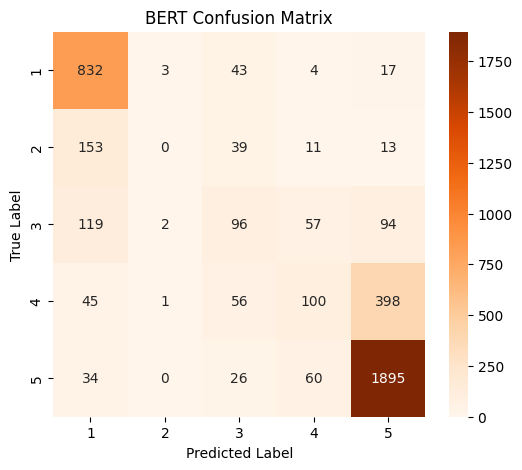

In [38]:
labels = ["1", "2", "3", "4", "5"]
bert_cm = confusion_matrix(test_true, test_pred)  # BERT模型的真实值和预测值
# 计算每个类别的 accuracy
class_accuracies = []
for i in range(len(bert_cm)):
    TP = bert_cm[i, i]  # 该类别的正确预测数量
    FN = np.sum(bert_cm[i, :]) - TP

    class_accuracy = TP / (TP + FN) if (TP + FN) > 0 else 0
    class_accuracies.append(class_accuracy)

# 计算 macro accuracy
macro_accuracy = np.mean(class_accuracies)
print(f" Macro Accuracy: {macro_accuracy:.4f}\n")

plt.figure(figsize=(6,5))
sns.heatmap(bert_cm, annot=True, fmt='d', cmap='Oranges', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('BERT Confusion Matrix')
plt.show()

Stopwords

In [39]:
import nltk
nltk.download('stopwords')
nltk.download('rslp')
pt_stopwords = stopwords.words('portuguese')
print(f'Total portuguese stopwords in the nltk.corpous module: {len(pt_stopwords)}')
pt_stopwords[:10]

Total portuguese stopwords in the nltk.corpous module: 207


[nltk_data] Downloading package stopwords to
[nltk_data]     /nfs/home/Tyrants/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package rslp to /nfs/home/Tyrants/nltk_data...
[nltk_data]   Package rslp is already up-to-date!


['a',
 'à',
 'ao',
 'aos',
 'aquela',
 'aquelas',
 'aquele',
 'aqueles',
 'aquilo',
 'as']

In [40]:
def stopwords_removal(text):
    return [c.lower() for c in text.split() if c.lower() not in pt_stopwords]

In [41]:
reviews_stopwords = [' '.join(stopwords_removal(review)) for review in reviews_whitespaces]
df_comments['stopwords_removed'] = reviews_stopwords
print(reviews_whitespaces[3])
print(reviews_stopwords[3])

Mas um pouco travando pelo valor ta Boa
pouco travando valor ta boa


Stemming

In [42]:
def stemming(text, stemmer=RSLPStemmer()):
    return [stemmer.stem(c) for c in text.split()]

In [43]:
reviews_stemmer = [' '.join(stemming(review)) for review in reviews_stopwords]
df_comments['stemming'] = reviews_stemmer
print(reviews_stopwords[3])
print(reviews_stemmer[3])

pouco travando valor ta boa
pouc trav val ta boa


Feature Extraction

1. 使用`CountVectorizer`将文本数据转换为词袋（Bag of Words, BoW）表示。通过`fit_transform()`统计每个词语在文本中出现的次数，生成一个词频矩阵。

In [44]:
def extract_features_from_corpus(corpus, vectorizer, df=False):
    
    # Extracting features
    corpus_features = vectorizer.fit_transform(corpus).toarray()
    features_names = vectorizer.get_feature_names_out()
    
    # Transforming into a dataframe to give interpretability to the process
    df_corpus_features = None
    if df:
        df_corpus_features = pd.DataFrame(corpus_features, columns=features_names)
    
    return corpus_features, df_corpus_features

`‌max_features‌=300`: 只保留出现频率最高的 300 个单词

`min_df=7`: 单词至少出现在7个文档中才会被保留

`max_df=0.8`: 单词出现在80%以上的文档时会被忽略

`stop_words=pt_stopwords`: 使用葡萄牙语停用词

In [45]:
count_vectorizer = CountVectorizer(max_features=300, min_df=7, max_df=0.8, stop_words=pt_stopwords)

# Extracting features for the corpus
countv_features, df_countv_features = extract_features_from_corpus(reviews_stemmer, count_vectorizer, df=True)
print(f'Shape of countv_features matrix: {countv_features.shape}\n')
df_countv_features.head()

Shape of countv_features matrix: (40977, 300)



,abr,acab,ach,acontec,acord,ador,adquir,agor,aguard,aind,...,vei,vem,vend,ver,vez,vier,volt,vou,ótim,únic
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0


由于BoW所有单词都具有相同的重要性，使用TF-IDF优化。
$$TF=\frac{\text{Frequency of a word in the document}}{\text{Total words in the document}}$$
$$IDF = \log\left({\frac{\text{Total number of docs}}{\text{Number of docs containing the words}}}\right)$$

In [46]:
# Creating an object for the CountVectorizer class
tfidf_vectorizer = TfidfVectorizer(max_features=300, min_df=7, max_df=0.8, stop_words=pt_stopwords, ngram_range=(1,3))

# Extracting features for the corpus
tfidf_features, df_tfidf_features = extract_features_from_corpus(reviews_stemmer, tfidf_vectorizer, df=True)
print(f'Shape of tfidf_features matrix: {tfidf_features.shape}\n')
df_tfidf_features.head()

Shape of tfidf_features matrix: (40977, 300)



,acab,ach,acontec,acord,ador,agor,agor neg,aguard,aind,aind neg,...,us,val,vc,vei,vend,vez,volt,vou,ótim,ótim produt
0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.00000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.326811,0.0,0.0,0.0,0.0,0.0,...,0.0,0.00000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.00000,0.0,0.0,0.000000,0.302035,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.59172,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.00000,0.0,0.0,0.383471,0.000000,0.0,0.0,0.0,0.0


Labelling Data

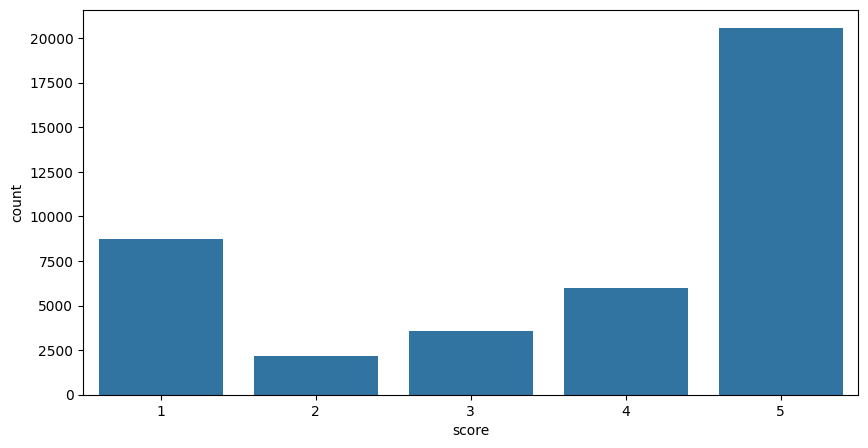

In [47]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.countplot(x='score', data=df_comments, ax=ax)
plt.show()

N-grams

In [48]:
def ngrams_count(corpus, ngram_range, n=-1, cached_stopwords=pt_stopwords):
    # Using CountVectorizer to build a bag of words using the given corpus
    vectorizer = CountVectorizer(stop_words=cached_stopwords, ngram_range=ngram_range).fit(corpus)
    bag_of_words = vectorizer.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    total_list = words_freq[:n]
    
    # Returning a DataFrame with the ngrams count
    count_df = pd.DataFrame(total_list, columns=['ngram', 'count'])
    return count_df

In [49]:
X_processed = tfidf_features
df_comments['sentiment_label'] = df_comments['score'] - 1
y = df_comments['sentiment_label'].tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.20, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_test, y_test, test_size=0.50, random_state=42, stratify=y_test
)
print(f'Length of X_train: {len(X_train)} - Length of one element: {len(X_train[0])}')
print(f'Length of X_test: {len(X_test)} - Length of one element: {len(X_test[0])}')

Length of X_train: 32781 - Length of one element: 300
Length of X_test: 4098 - Length of one element: 300


# Sentiment Classification

In [50]:
# Logistic Regression hyperparameters
logreg_param_grid = {
    'C': np.linspace(0.1, 10, 20),
    'penalty': ['l1', 'l2'],
    'class_weight': ['balanced', None],
    'random_state': [42],
    'solver': ['liblinear']
}

svm_param_grid = {
    'C': np.logspace(-2, 2, 10),
    'kernel': ['linear'],
    'class_weight': ['balanced', None],
    'random_state': [42]
}

xgb_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.7, 1.0],
    'colsample_bytree': [0.7, 1.0],
    'gamma': [0, 0.1, 0.3],
    'random_state': [42]
}

# Setting up the classifiers
set_classifiers = {
    'XGBoost': {
        'model': XGBClassifier(eval_metric='mlogloss'),  # 适用于多分类任务
        'params': xgb_param_grid
    },
    'LogisticRegression': {
        'model': LogisticRegression(),
        'params': logreg_param_grid
    },
    'Naive Bayes': {
        'model': GaussianNB(),
        'params': {}
    },
    'SVM': {
        'model': SVC(),
        'params': svm_param_grid
    }
}

In [57]:
best_models = {}

for name, clf_info in set_classifiers.items():
    print(f"Training {name}...")
    
    model = clf_info['model']
    param_grid = clf_info['params']

    if name in ["LogisticRegression", "SVM", "XGBoost"]:
        best_score = 0
        best_params = None
        best_model = None

        for params in ParameterSampler(param_grid, n_iter=10, random_state=42):  # 随机选择 10 组参数
            model.set_params(**params)  # 设置超参数
            model.fit(X_train, y_train)  # 训练
            score = model.score(X_val, y_val)  # 在验证集上评估
            
            if score > best_score:
                best_score = score
                best_params = params
                best_model = model
        
        # 用最佳超参数重新训练模型
        best_model.fit(X_train, y_train)
        best_models[name] = best_model
        print(f"Best parameters for {name}: {best_params}\n")

    #  Naive Bayes 没有超参数调优，直接训练
    else:
        model.fit(X_train, y_train)
        best_models[name] = model
        
    best_models[name] = model


Training XGBoost...


/nfs/home/Tyrants/venv/lib/python3.8/site-packages/xgboost/core.py:158: UserWarning: [14:04:02] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/nfs/home/Tyrants/venv/lib/python3.8/site-packages/xgboost/core.py:158: UserWarning: [14:04:04] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/nfs/home/Tyrants/venv/lib/python3.8/site-packages/xgboost/core.py:158: UserWarning: [14:04:05] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/nfs/home/Tyrants/venv/lib/python3.8/site-packages/xgboost/core.py:158: UserWarning: [14:04:11] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/nfs/home/Tyrants/venv/lib/python3.8/site-packages/xgboost/core.py:158: UserWarning: [14:04:15] WARNING: /wo

Best parameters for XGBoost: {'subsample': 0.7, 'random_state': 42, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 1.0}

Training LogisticRegression...
Best parameters for LogisticRegression: {'solver': 'liblinear', 'random_state': 42, 'penalty': 'l1', 'class_weight': None, 'C': 2.7052631578947373}

Training Naive Bayes...
Training SVM...
Best parameters for SVM: {'random_state': 42, 'kernel': 'linear', 'class_weight': None, 'C': 35.93813663804626}




 Classification Report for XGBoost:
              precision    recall  f1-score   support

           1       0.62      0.80      0.70       875
           2       0.17      0.00      0.01       214
           3       0.32      0.03      0.06       356
           4       0.35      0.05      0.08       598
           5       0.69      0.96      0.81      2055

    accuracy                           0.66      4098
   macro avg       0.43      0.37      0.33      4098
weighted avg       0.57      0.66      0.57      4098

 Macro Accuracy: 0.3689



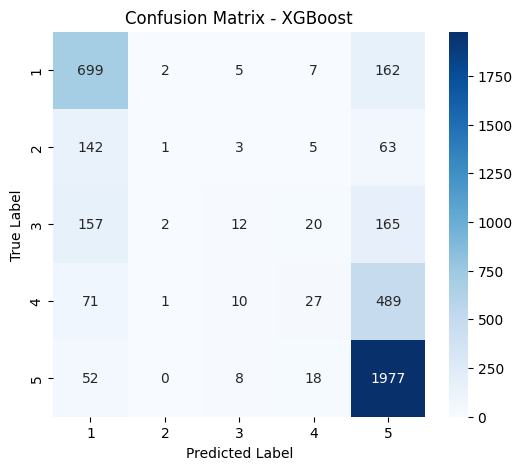


 Classification Report for LogisticRegression:
              precision    recall  f1-score   support

           1       0.68      0.77      0.72       875
           2       0.15      0.17      0.16       214
           3       0.28      0.23      0.25       356
           4       0.29      0.14      0.19       598
           5       0.79      0.87      0.83      2055

    accuracy                           0.65      4098
   macro avg       0.44      0.44      0.43      4098
weighted avg       0.61      0.65      0.63      4098

 Macro Accuracy: 0.4361



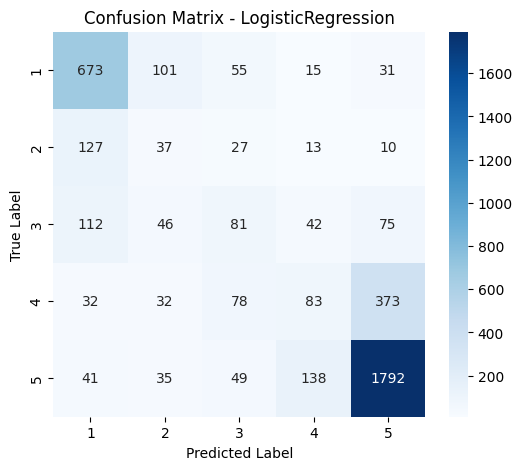


 Classification Report for Naive Bayes:
              precision    recall  f1-score   support

           1       0.56      0.86      0.68       875
           2       0.10      0.19      0.13       214
           3       0.17      0.06      0.08       356
           4       0.27      0.09      0.14       598
           5       0.79      0.79      0.79      2055

    accuracy                           0.61      4098
   macro avg       0.38      0.40      0.37      4098
weighted avg       0.58      0.61      0.58      4098

 Macro Accuracy: 0.3974



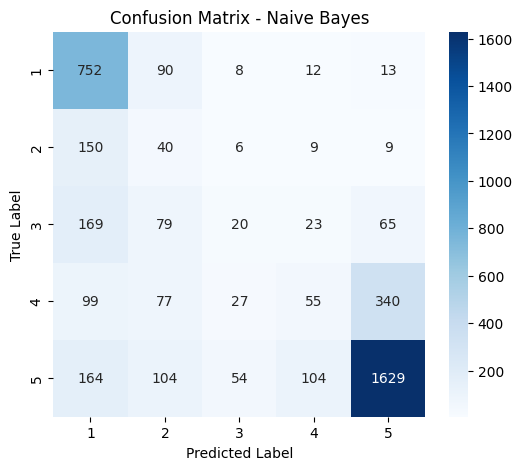


 Classification Report for SVM:
              precision    recall  f1-score   support

           1       0.73      0.59      0.66       875
           2       0.15      0.38      0.22       214
           3       0.21      0.28      0.24       356
           4       0.28      0.35      0.31       598
           5       0.85      0.67      0.75      2055

    accuracy                           0.56      4098
   macro avg       0.45      0.46      0.44      4098
weighted avg       0.65      0.56      0.59      4098

 Macro Accuracy: 0.4563



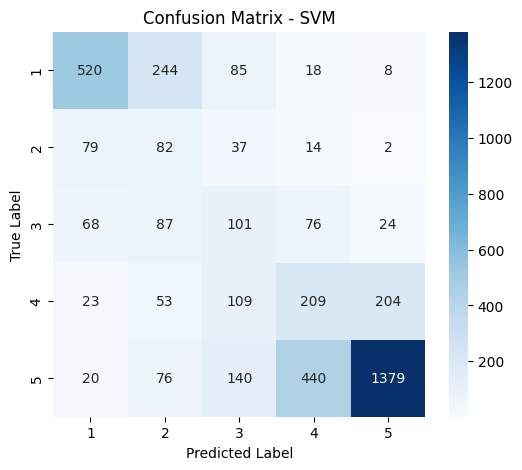

In [58]:
for name, model in best_models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    # 计算每个类别的 accuracy
    class_accuracies = []
    for i in range(len(cm)):
        TP = cm[i, i]  # 该类别的正确预测数量
        FN = np.sum(cm[i, :]) - TP

        class_accuracy = TP / (TP + FN) if (TP + FN) > 0 else 0
        class_accuracies.append(class_accuracy)

    # 计算 macro accuracy
    macro_accuracy = np.mean(class_accuracies)
    
    print(f"\n Classification Report for {name}:")
    print(classification_report(y_test, y_pred, target_names=["1", "2", "3", "4", "5"]))
    print(f" Macro Accuracy: {macro_accuracy:.4f}\n")
    
    # 绘制混淆矩阵
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'Confusion Matrix - {name}')
    plt.show()